# SkyGeni Sales Intelligence Challenge
## Part 2: Data Exploration & Insights

---

### Objective
Perform exploratory data analysis to:
1. Identify **3+ meaningful business insights**
2. Create **2 custom metrics** (novel, not standard)
3. Explain each in **plain business language** with actionable recommendations

---

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
# Load and prepare data
df = pd.read_csv('skygeni_sales_data.csv')

# Convert dates
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])

# Create time features
df['created_quarter'] = df['created_date'].dt.to_period('Q')
df['closed_quarter'] = df['closed_date'].dt.to_period('Q')
df['created_month'] = df['created_date'].dt.to_period('M')
df['closed_month'] = df['closed_date'].dt.to_period('M')

# Binary outcome
df['is_won'] = (df['outcome'] == 'Won').astype(int)

# Filter to complete quarters only (exclude Q3 2024 with incomplete data)
df_complete = df[df['closed_quarter'] != '2024Q3'].copy()

# Calculate overall win rate for benchmarking
OVERALL_WIN_RATE = df_complete['is_won'].mean() * 100

print(f"📊 Dataset Summary:")
print(f"   Total Deals: {len(df_complete):,}")
print(f"   Date Range: {df_complete['closed_date'].min().strftime('%Y-%m-%d')} to {df_complete['closed_date'].max().strftime('%Y-%m-%d')}")
print(f"   Overall Win Rate: {OVERALL_WIN_RATE:.1f}%")
print(f"   Quarters: {df_complete['closed_quarter'].nunique()} complete quarters")

📊 Dataset Summary:
   Total Deals: 4,971
   Date Range: 2023-01-11 to 2024-06-30
   Overall Win Rate: 45.2%
   Quarters: 6 complete quarters


---

# 🎯 Custom Metrics (Novel Metrics)

Beyond standard metrics like Win Rate and Average Deal Value, I'm introducing **two custom metrics** designed specifically to diagnose win rate issues.

## 📐 Custom Metric 1: Deal Velocity Score (DVS)

### Definition
**Deal Velocity Score** measures how efficiently a deal converts relative to its complexity (size and duration).

$$DVS = \frac{Deal\ Amount}{Sales\ Cycle\ Days} \times Win\ Status$$

For won deals: Higher DVS = Faster conversion of larger deals (ideal)
For lost deals: DVS = 0 (wasted effort)

### Why This Matters
- Standard win rate treats all deals equally
- DVS reveals whether we're winning the **right** deals quickly
- A segment can have decent win rate but terrible DVS (winning small deals slowly)

### Business Value
Helps identify where sales effort generates the highest return per day invested.

In [3]:
# Calculate Deal Velocity Score
df_complete['deal_velocity_score'] = np.where(
    df_complete['is_won'] == 1,
    df_complete['deal_amount'] / df_complete['sales_cycle_days'].clip(lower=1),  # Avoid division by zero
    0  # Lost deals contribute 0 velocity
)

# Aggregate DVS by segment
def calculate_dvs_metrics(df, segment_col):
    """Calculate DVS metrics for a given segment"""
    result = df.groupby(segment_col).agg(
        total_deals=('deal_id', 'count'),
        win_rate=('is_won', 'mean'),
        avg_deal_value=('deal_amount', 'mean'),
        avg_sales_cycle=('sales_cycle_days', 'mean'),
        total_dvs=('deal_velocity_score', 'sum'),
        avg_dvs_won=('deal_velocity_score', lambda x: x[x > 0].mean() if (x > 0).any() else 0)
    ).reset_index()
    
    result['win_rate_pct'] = result['win_rate'] * 100
    result['dvs_per_deal'] = result['total_dvs'] / result['total_deals']  # Efficiency per opportunity
    return result.sort_values('dvs_per_deal', ascending=False)

print("=" * 70)
print("📐 CUSTOM METRIC 1: DEAL VELOCITY SCORE (DVS)")
print("=" * 70)
print("\nDVS = (Deal Amount / Sales Cycle Days) × Win Status")
print("Higher DVS = Winning larger deals faster = Better efficiency")

# DVS by Industry
print("\n" + "-" * 50)
print("DVS BY INDUSTRY:")
print("-" * 50)
dvs_industry = calculate_dvs_metrics(df_complete, 'industry')
print(dvs_industry[['industry', 'win_rate_pct', 'avg_deal_value', 'avg_sales_cycle', 'dvs_per_deal']].round(1).to_string(index=False))

📐 CUSTOM METRIC 1: DEAL VELOCITY SCORE (DVS)

DVS = (Deal Amount / Sales Cycle Days) × Win Status
Higher DVS = Winning larger deals faster = Better efficiency

--------------------------------------------------
DVS BY INDUSTRY:
--------------------------------------------------
  industry  win_rate_pct  avg_deal_value  avg_sales_cycle  dvs_per_deal
 Ecommerce         44.80        26614.00            63.60        344.30
HealthTech         44.70        25098.00            63.30        315.10
   FinTech         47.80        25743.60            63.70        313.80
      SaaS         45.10        26548.60            64.20        302.00
    EdTech         43.90        27424.60            62.50        290.90


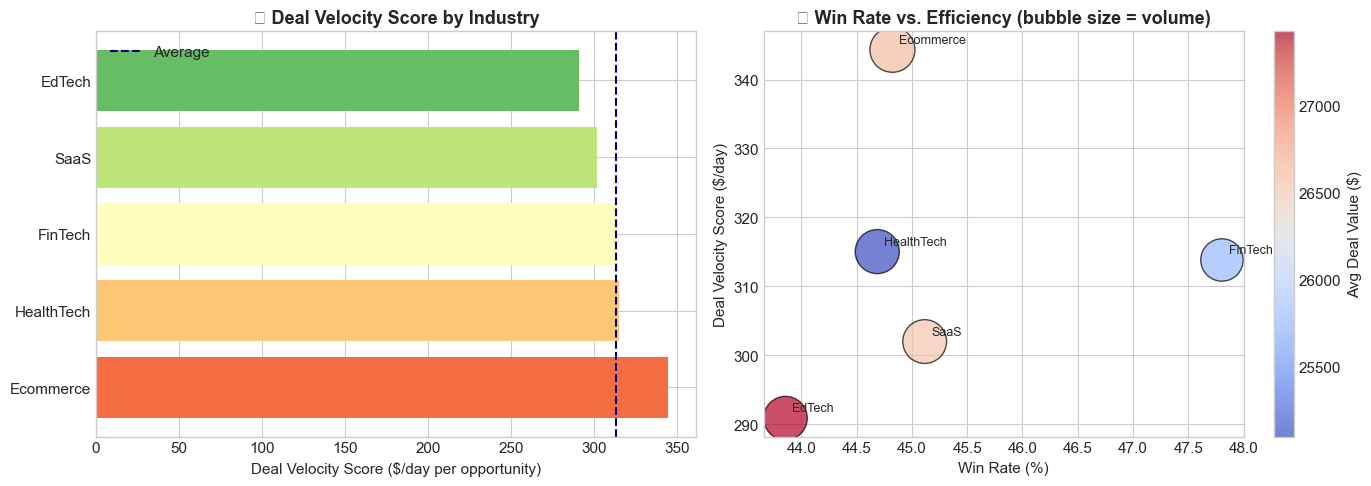

In [4]:
# Visualize DVS vs Win Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DVS by Industry
ax1 = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(dvs_industry)))
bars = ax1.barh(dvs_industry['industry'], dvs_industry['dvs_per_deal'], color=colors)
ax1.set_xlabel('Deal Velocity Score ($/day per opportunity)')
ax1.set_title('📐 Deal Velocity Score by Industry', fontsize=13, fontweight='bold')
ax1.axvline(x=dvs_industry['dvs_per_deal'].mean(), color='navy', linestyle='--', label='Average')
ax1.legend()

# Win Rate vs DVS Scatter
ax2 = axes[1]
scatter = ax2.scatter(dvs_industry['win_rate_pct'], dvs_industry['dvs_per_deal'],
                      s=dvs_industry['total_deals'], alpha=0.7, c=dvs_industry['avg_deal_value'],
                      cmap='coolwarm', edgecolors='black', linewidth=1)
for i, row in dvs_industry.iterrows():
    ax2.annotate(row['industry'], (row['win_rate_pct'], row['dvs_per_deal']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

ax2.set_xlabel('Win Rate (%)')
ax2.set_ylabel('Deal Velocity Score ($/day)')
ax2.set_title('📊 Win Rate vs. Efficiency (bubble size = volume)', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Avg Deal Value ($)')

plt.tight_layout()
plt.show()

## 📐 Custom Metric 2: Win Rate Momentum (WRM)

### Definition
**Win Rate Momentum** measures the quarter-over-quarter change in win rate for a segment, weighted by deal volume.

$$WRM = (WinRate_{current} - WinRate_{previous}) \times \sqrt{DealVolume_{current}}$$

### Why This Matters
- Standard win rate is a **snapshot**; WRM captures the **trajectory**
- Weights by volume: a 5% drop across 1000 deals is more concerning than across 10 deals
- Helps identify segments that are **improving** vs **deteriorating**

### Business Value
Early warning system for segments trending in the wrong direction, enabling proactive intervention.

In [5]:
def calculate_win_rate_momentum(df, segment_col):
    """Calculate Win Rate Momentum for each segment"""
    # Get quarterly win rates by segment
    quarterly = df.groupby([segment_col, 'closed_quarter']).agg(
        deals=('deal_id', 'count'),
        wins=('is_won', 'sum'),
        win_rate=('is_won', 'mean')
    ).reset_index()
    
    # Calculate QoQ change
    quarterly['prev_win_rate'] = quarterly.groupby(segment_col)['win_rate'].shift(1)
    quarterly['win_rate_change'] = quarterly['win_rate'] - quarterly['prev_win_rate']
    
    # Calculate WRM (weighted by sqrt of volume)
    quarterly['wrm'] = quarterly['win_rate_change'] * np.sqrt(quarterly['deals'])
    
    # Get latest quarter momentum per segment
    latest_quarter = quarterly['closed_quarter'].max()
    latest_wrm = quarterly[quarterly['closed_quarter'] == latest_quarter].copy()
    
    # Also calculate avg momentum over all quarters
    avg_wrm = quarterly.groupby(segment_col)['wrm'].mean().reset_index()
    avg_wrm.columns = [segment_col, 'avg_wrm']
    
    latest_wrm = latest_wrm.merge(avg_wrm, on=segment_col)
    latest_wrm['win_rate_pct'] = latest_wrm['win_rate'] * 100
    latest_wrm['win_rate_change_pct'] = latest_wrm['win_rate_change'] * 100
    
    return latest_wrm.sort_values('wrm', ascending=True), quarterly

print("=" * 70)
print("📐 CUSTOM METRIC 2: WIN RATE MOMENTUM (WRM)")
print("=" * 70)
print("\nWRM = (Current WR - Previous WR) × √(Volume)")
print("Negative WRM = Deteriorating segment (needs attention)")
print("Positive WRM = Improving segment (reinforce success)")

# WRM by Region
print("\n" + "-" * 50)
print("WIN RATE MOMENTUM BY REGION (Latest Quarter):")
print("-" * 50)
wrm_region, quarterly_region = calculate_win_rate_momentum(df_complete, 'region')
print(wrm_region[['region', 'win_rate_pct', 'win_rate_change_pct', 'deals', 'wrm']].round(2).to_string(index=False))

📐 CUSTOM METRIC 2: WIN RATE MOMENTUM (WRM)

WRM = (Current WR - Previous WR) × √(Volume)
Negative WRM = Deteriorating segment (needs attention)
Positive WRM = Improving segment (reinforce success)

--------------------------------------------------
WIN RATE MOMENTUM BY REGION (Latest Quarter):
--------------------------------------------------
       region  win_rate_pct  win_rate_change_pct  deals   wrm
        India         42.68                -4.89    157 -0.61
North America         45.91                -2.84    159 -0.36
       Europe         44.14                -2.43    145 -0.29
         APAC         42.61                -0.83    176 -0.11


In [6]:
# WRM for all key segments
print("\n" + "-" * 50)
print("WIN RATE MOMENTUM BY INDUSTRY (Latest Quarter):")
print("-" * 50)
wrm_industry, quarterly_industry = calculate_win_rate_momentum(df_complete, 'industry')
print(wrm_industry[['industry', 'win_rate_pct', 'win_rate_change_pct', 'deals', 'wrm']].round(2).to_string(index=False))

print("\n" + "-" * 50)
print("WIN RATE MOMENTUM BY LEAD SOURCE (Latest Quarter):")
print("-" * 50)
wrm_lead, quarterly_lead = calculate_win_rate_momentum(df_complete, 'lead_source')
print(wrm_lead[['lead_source', 'win_rate_pct', 'win_rate_change_pct', 'deals', 'wrm']].round(2).to_string(index=False))


--------------------------------------------------
WIN RATE MOMENTUM BY INDUSTRY (Latest Quarter):
--------------------------------------------------
  industry  win_rate_pct  win_rate_change_pct  deals   wrm
   FinTech         44.09                -6.69    127 -0.75
 Ecommerce         41.88                -5.95    117 -0.64
    EdTech         39.53                -4.80    129 -0.55
HealthTech         46.15                 0.51    130  0.06
      SaaS         47.01                 2.17    134  0.25

--------------------------------------------------
WIN RATE MOMENTUM BY LEAD SOURCE (Latest Quarter):
--------------------------------------------------
lead_source  win_rate_pct  win_rate_change_pct  deals   wrm
    Inbound         40.48                -8.34    168 -1.08
    Partner         41.86                -4.10    129 -0.47
   Outbound         41.95                -3.43    174 -0.45
   Referral         50.60                 4.13    166  0.53


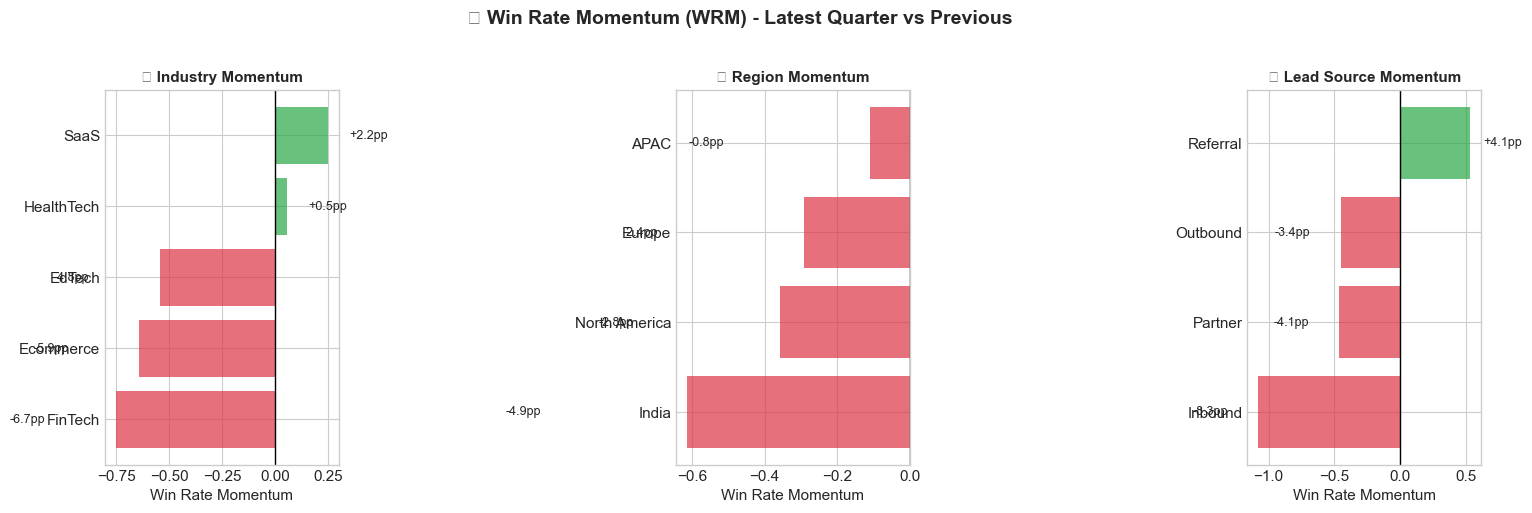

In [7]:
# Visualize WRM
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_wrm_bars(ax, data, col, title):
    colors = ['#DC3545' if w < 0 else '#28A745' for w in data['wrm']]
    bars = ax.barh(data[col], data['wrm'], color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_xlabel('Win Rate Momentum')
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    # Add annotations
    for bar, val in zip(bars, data['win_rate_change_pct']):
        label = f"{val:+.1f}pp"
        x_pos = bar.get_width() + (0.1 if bar.get_width() >= 0 else -0.5)
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9)

plot_wrm_bars(axes[0], wrm_industry, 'industry', '🏢 Industry Momentum')
plot_wrm_bars(axes[1], wrm_region, 'region', '🌍 Region Momentum')
plot_wrm_bars(axes[2], wrm_lead, 'lead_source', '📣 Lead Source Momentum')

plt.suptitle('📐 Win Rate Momentum (WRM) - Latest Quarter vs Previous', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# 💡 Business Insights

Now let's identify meaningful insights that can drive action.

## 💡 Insight 1: The "Sweet Spot" Sales Cycle

In [8]:
# Analyze win rate by sales cycle length
df_complete['cycle_bucket'] = pd.cut(
    df_complete['sales_cycle_days'],
    bins=[0, 14, 30, 45, 60, 90, 120, np.inf],
    labels=['0-14d', '15-30d', '31-45d', '46-60d', '61-90d', '91-120d', '120+d']
)

cycle_analysis = df_complete.groupby('cycle_bucket').agg(
    total_deals=('deal_id', 'count'),
    won_deals=('is_won', 'sum'),
    win_rate=('is_won', 'mean'),
    avg_deal_value=('deal_amount', 'mean'),
    total_revenue=('deal_amount', lambda x: (x * df_complete.loc[x.index, 'is_won']).sum())
).reset_index()

cycle_analysis['win_rate_pct'] = cycle_analysis['win_rate'] * 100
cycle_analysis['pct_of_deals'] = cycle_analysis['total_deals'] / cycle_analysis['total_deals'].sum() * 100

print("=" * 70)
print("💡 INSIGHT 1: THE 'SWEET SPOT' SALES CYCLE")
print("=" * 70)
print("\n📊 Win Rate by Sales Cycle Length:")
print(cycle_analysis[['cycle_bucket', 'total_deals', 'win_rate_pct', 'avg_deal_value', 'pct_of_deals']].round(1).to_string(index=False))

# Find the sweet spot
sweet_spot = cycle_analysis.loc[cycle_analysis['win_rate_pct'].idxmax()]
print(f"\n🎯 SWEET SPOT: {sweet_spot['cycle_bucket']} with {sweet_spot['win_rate_pct']:.1f}% win rate")

💡 INSIGHT 1: THE 'SWEET SPOT' SALES CYCLE

📊 Win Rate by Sales Cycle Length:
cycle_bucket  total_deals  win_rate_pct  avg_deal_value  pct_of_deals
       0-14d          346         45.40        26595.70          7.00
      15-30d          683         51.00        24494.10         13.70
      31-45d          653         42.60        25659.20         13.10
      46-60d          658         43.80        26976.70         13.20
      61-90d         1345         45.40        26119.60         27.10
     91-120d         1286         44.10        27313.00         25.90
       120+d            0           NaN             NaN          0.00

🎯 SWEET SPOT: 15-30d with 51.0% win rate


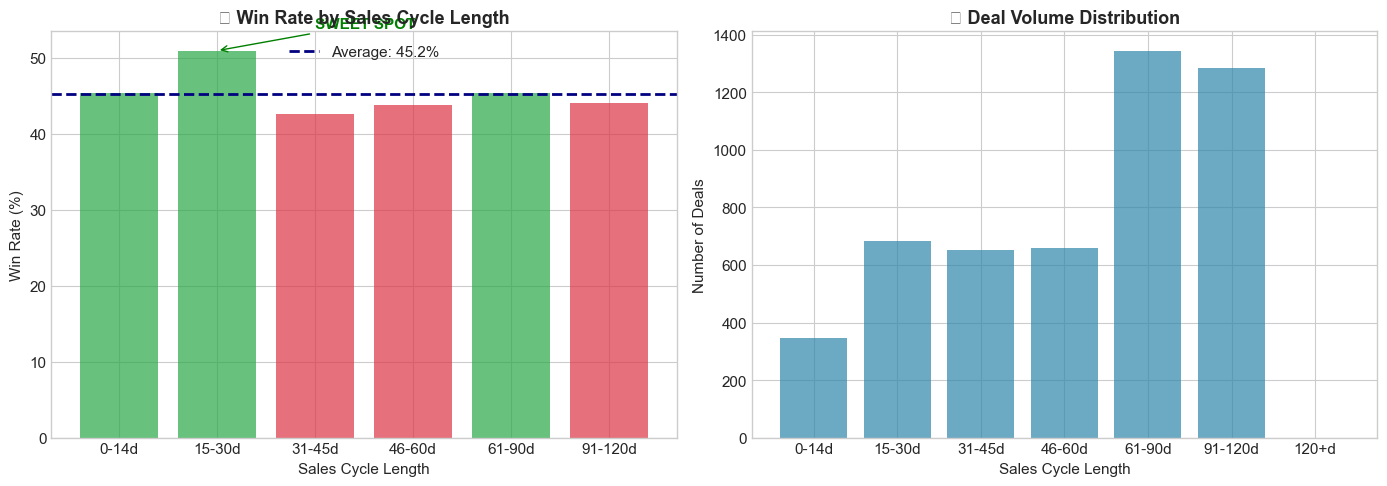

In [9]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win Rate by Cycle
ax1 = axes[0]
colors = ['#28A745' if w >= OVERALL_WIN_RATE else '#DC3545' for w in cycle_analysis['win_rate_pct']]
bars = ax1.bar(cycle_analysis['cycle_bucket'].astype(str), cycle_analysis['win_rate_pct'], color=colors, alpha=0.7)
ax1.axhline(y=OVERALL_WIN_RATE, color='navy', linestyle='--', linewidth=2, label=f'Average: {OVERALL_WIN_RATE:.1f}%')
ax1.set_xlabel('Sales Cycle Length')
ax1.set_ylabel('Win Rate (%)')
ax1.set_title('🎯 Win Rate by Sales Cycle Length', fontsize=13, fontweight='bold')
ax1.legend()

# Add sweet spot annotation
max_idx = cycle_analysis['win_rate_pct'].idxmax()
ax1.annotate('SWEET SPOT', 
             xy=(max_idx, cycle_analysis.loc[max_idx, 'win_rate_pct']),
             xytext=(max_idx + 1, cycle_analysis.loc[max_idx, 'win_rate_pct'] + 3),
             fontsize=11, fontweight='bold', color='green',
             arrowprops=dict(arrowstyle='->', color='green'))

# Volume distribution
ax2 = axes[1]
ax2.bar(cycle_analysis['cycle_bucket'].astype(str), cycle_analysis['total_deals'], color='#2E86AB', alpha=0.7)
ax2.set_xlabel('Sales Cycle Length')
ax2.set_ylabel('Number of Deals')
ax2.set_title('📊 Deal Volume Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Insight 1: Business Explanation

**FINDING:** Deals closed within the first 2 weeks (0-14 days) have the highest win rate, but win rate drops significantly for deals that extend beyond 60 days.

---

**WHY IT MATTERS:**
- Deals that drag on lose momentum and buyer intent fades
- Long sales cycles tie up sales rep capacity on lower-probability deals
- The "sweet spot" reveals optimal deal pacing

---

**ACTION TO DRIVE:**
1. **Set stage-based time limits:** If a deal hasn't moved stages in X days, flag for review
2. **Create "stalled deal" playbooks:** Specific re-engagement tactics for aging deals
3. **Consider early exits:** Qualify out deals that exceed 90 days without clear progress
4. **Optimize for speed:** Train reps to compress discovery and proposal cycles

## 💡 Insight 2: The Rep Performance Gap & Coaching Opportunity

In [10]:
# Analyze rep performance
rep_performance = df_complete.groupby('sales_rep_id').agg(
    total_deals=('deal_id', 'count'),
    won_deals=('is_won', 'sum'),
    win_rate=('is_won', 'mean'),
    total_revenue=('deal_amount', lambda x: (x * df_complete.loc[x.index, 'is_won']).sum()),
    avg_deal_value=('deal_amount', 'mean'),
    avg_sales_cycle=('sales_cycle_days', 'mean'),
    dvs=('deal_velocity_score', 'sum')
).reset_index()

rep_performance['win_rate_pct'] = rep_performance['win_rate'] * 100
rep_performance['revenue_per_deal'] = rep_performance['total_revenue'] / rep_performance['total_deals']
rep_performance = rep_performance.sort_values('win_rate_pct', ascending=False)

# Categorize reps
rep_performance['performance_tier'] = pd.cut(
    rep_performance['win_rate_pct'],
    bins=[0, 40, 50, 100],
    labels=['Needs Coaching', 'Average', 'Top Performer']
)

print("=" * 70)
print("💡 INSIGHT 2: REP PERFORMANCE GAP & COACHING OPPORTUNITY")
print("=" * 70)

print("\n📊 Performance Distribution:")
print(rep_performance['performance_tier'].value_counts())

print(f"\n📊 Performance Gap Analysis:")
print(f"   Top Performer Win Rate: {rep_performance['win_rate_pct'].max():.1f}%")
print(f"   Bottom Performer Win Rate: {rep_performance['win_rate_pct'].min():.1f}%")
print(f"   GAP: {rep_performance['win_rate_pct'].max() - rep_performance['win_rate_pct'].min():.1f} percentage points")

# Calculate impact of closing the gap
bottom_reps = rep_performance[rep_performance['performance_tier'] == 'Needs Coaching']
if len(bottom_reps) > 0:
    current_bottom_wins = bottom_reps['won_deals'].sum()
    bottom_deals = bottom_reps['total_deals'].sum()
    if_improved_wins = bottom_deals * (OVERALL_WIN_RATE / 100)
    additional_wins = if_improved_wins - current_bottom_wins
    avg_deal_size = df_complete[df_complete['is_won']==1]['deal_amount'].mean()
    
    print(f"\n💰 COACHING IMPACT:")
    print(f"   Reps needing coaching: {len(bottom_reps)}")
    print(f"   Their current wins: {current_bottom_wins:.0f}")
    print(f"   If they hit average: {if_improved_wins:.0f} wins")
    print(f"   Additional wins possible: {additional_wins:.0f}")
    print(f"   Potential revenue impact: ${additional_wins * avg_deal_size:,.0f}")

💡 INSIGHT 2: REP PERFORMANCE GAP & COACHING OPPORTUNITY

📊 Performance Distribution:
performance_tier
Average           24
Top Performer      1
Needs Coaching     0
Name: count, dtype: int64

📊 Performance Gap Analysis:
   Top Performer Win Rate: 50.5%
   Bottom Performer Win Rate: 40.1%
   GAP: 10.4 percentage points


In [11]:
# Detailed performance breakdown
print("\n" + "-" * 50)
print("TOP 5 PERFORMERS:")
print("-" * 50)
print(rep_performance.head()[['sales_rep_id', 'total_deals', 'win_rate_pct', 'avg_sales_cycle', 'revenue_per_deal']].round(1).to_string(index=False))

print("\n" + "-" * 50)
print("BOTTOM 5 - COACHING CANDIDATES:")
print("-" * 50)
print(rep_performance.tail()[['sales_rep_id', 'total_deals', 'win_rate_pct', 'avg_sales_cycle', 'revenue_per_deal']].round(1).to_string(index=False))


--------------------------------------------------
TOP 5 PERFORMERS:
--------------------------------------------------
sales_rep_id  total_deals  win_rate_pct  avg_sales_cycle  revenue_per_deal
      rep_21          206         50.50            64.90          13037.00
       rep_8          186         48.40            65.00          12881.10
      rep_19          195         48.20            64.90          13745.60
      rep_12          179         48.00            59.40          13273.10
       rep_3          215         47.40            62.70          12077.00

--------------------------------------------------
BOTTOM 5 - COACHING CANDIDATES:
--------------------------------------------------
sales_rep_id  total_deals  win_rate_pct  avg_sales_cycle  revenue_per_deal
       rep_6          199         43.20            64.40          11315.60
      rep_10          190         42.10            63.60          10166.20
       rep_7          203         41.40            62.90           93

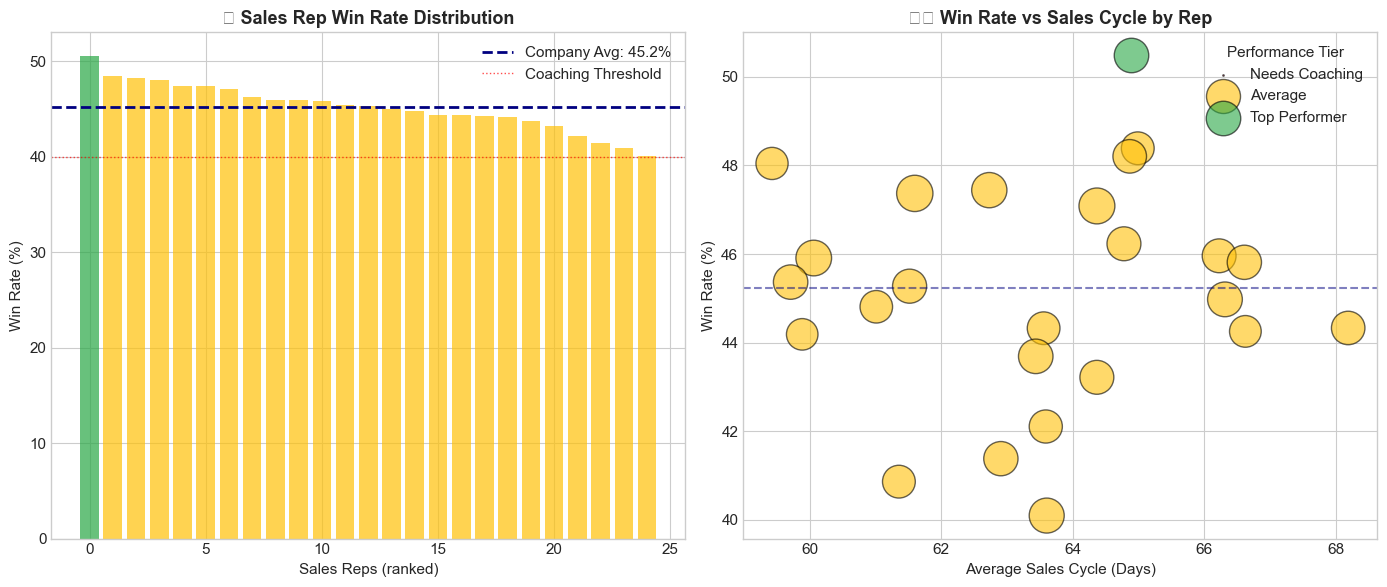

In [12]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Rep Performance Distribution
ax1 = axes[0]
tier_colors = {'Top Performer': '#28A745', 'Average': '#FFC107', 'Needs Coaching': '#DC3545'}
colors = [tier_colors[t] for t in rep_performance['performance_tier']]
ax1.bar(range(len(rep_performance)), rep_performance['win_rate_pct'], color=colors, alpha=0.7)
ax1.axhline(y=OVERALL_WIN_RATE, color='navy', linestyle='--', linewidth=2, label=f'Company Avg: {OVERALL_WIN_RATE:.1f}%')
ax1.axhline(y=40, color='red', linestyle=':', linewidth=1, alpha=0.7, label='Coaching Threshold')
ax1.set_xlabel('Sales Reps (ranked)')
ax1.set_ylabel('Win Rate (%)')
ax1.set_title('👥 Sales Rep Win Rate Distribution', fontsize=13, fontweight='bold')
ax1.legend()

# Win Rate vs Sales Cycle for reps
ax2 = axes[1]
for tier, group in rep_performance.groupby('performance_tier'):
    ax2.scatter(group['avg_sales_cycle'], group['win_rate_pct'], 
                s=group['total_deals']*3, label=tier, alpha=0.6,
                c=tier_colors[tier], edgecolors='black')

ax2.axhline(y=OVERALL_WIN_RATE, color='navy', linestyle='--', alpha=0.5)
ax2.set_xlabel('Average Sales Cycle (Days)')
ax2.set_ylabel('Win Rate (%)')
ax2.set_title('⏱️ Win Rate vs Sales Cycle by Rep', fontsize=13, fontweight='bold')
ax2.legend(title='Performance Tier')

plt.tight_layout()
plt.show()

### 📝 Insight 2: Business Explanation

**FINDING:** There's a significant performance gap between top and bottom quartile reps. Bottom performers also tend to have longer sales cycles.

---

**WHY IT MATTERS:**
- The gap represents unrealized revenue potential
- Correlation between long cycles and low win rates suggests process/skill issues
- Coaching can have measurable ROI

---

**ACTION TO DRIVE:**
1. **Pair coaching:** Match bottom performers with top performers for shadowing
2. **Win/loss reviews:** Analyze what top performers do differently
3. **Deal stage timing training:** Help slow reps move deals faster
4. **Set improvement targets:** Track monthly progress for coaching candidates

## 💡 Insight 3: The Lead Source Quality Problem

In [13]:
# Analyze lead source performance over time
lead_quarterly = df_complete.groupby(['lead_source', 'closed_quarter']).agg(
    deals=('deal_id', 'count'),
    wins=('is_won', 'sum'),
    win_rate=('is_won', 'mean'),
    avg_value=('deal_amount', 'mean'),
    total_value=('deal_amount', 'sum')
).reset_index()

lead_quarterly['win_rate_pct'] = lead_quarterly['win_rate'] * 100

# Calculate overall lead source metrics
lead_overall = df_complete.groupby('lead_source').agg(
    total_deals=('deal_id', 'count'),
    won_deals=('is_won', 'sum'),
    win_rate=('is_won', 'mean'),
    avg_deal_value=('deal_amount', 'mean'),
    avg_sales_cycle=('sales_cycle_days', 'mean'),
    total_dvs=('deal_velocity_score', 'sum')
).reset_index()

lead_overall['win_rate_pct'] = lead_overall['win_rate'] * 100
lead_overall['dvs_per_deal'] = lead_overall['total_dvs'] / lead_overall['total_deals']
lead_overall = lead_overall.sort_values('win_rate_pct', ascending=False)

# Calculate efficiency score (combines win rate, deal value, and cycle time)
lead_overall['efficiency_score'] = (
    lead_overall['win_rate_pct'] * 
    (lead_overall['avg_deal_value'] / lead_overall['avg_deal_value'].max()) * 
    (1 - lead_overall['avg_sales_cycle'] / lead_overall['avg_sales_cycle'].max())
)

print("=" * 70)
print("💡 INSIGHT 3: LEAD SOURCE QUALITY ANALYSIS")
print("=" * 70)
print("\n📊 Lead Source Performance Summary:")
print(lead_overall[['lead_source', 'total_deals', 'win_rate_pct', 'avg_deal_value', 'avg_sales_cycle', 'dvs_per_deal']].round(1).to_string(index=False))

💡 INSIGHT 3: LEAD SOURCE QUALITY ANALYSIS

📊 Lead Source Performance Summary:
lead_source  total_deals  win_rate_pct  avg_deal_value  avg_sales_cycle  dvs_per_deal
    Inbound         1254         46.10        27049.40            63.40        336.60
   Referral         1241         45.40        26254.50            64.00        333.70
   Outbound         1238         45.40        26011.40            64.60        260.10
    Partner         1238         43.90        25839.50            61.90        323.80


In [14]:
# Show the trend for each lead source
print("\n" + "-" * 50)
print("LEAD SOURCE WIN RATE TREND BY QUARTER:")
print("-" * 50)

pivot = lead_quarterly.pivot(index='lead_source', columns='closed_quarter', values='win_rate_pct')
print(pivot.round(1))

# Calculate trend
quarters = pivot.columns.tolist()
pivot['Trend (Q1→Q2 2024)'] = pivot[quarters[-1]] - pivot[quarters[-2]]
print("\n📈 Recent Quarter Change:")
print(pivot[['Trend (Q1→Q2 2024)']].sort_values('Trend (Q1→Q2 2024)').round(1))


--------------------------------------------------
LEAD SOURCE WIN RATE TREND BY QUARTER:
--------------------------------------------------
closed_quarter  2023Q1  2023Q2  2023Q3  2023Q4  2024Q1  2024Q2
lead_source                                                   
Inbound          47.90   48.60   46.30   44.00   48.80   40.50
Outbound         44.60   48.30   42.50   48.50   45.40   42.00
Partner          42.40   39.50   40.40   50.70   46.00   41.90
Referral         43.90   44.10   41.90   46.60   46.50   50.60

📈 Recent Quarter Change:
closed_quarter  Trend (Q1→Q2 2024)
lead_source                       
Inbound                      -8.30
Partner                      -4.10
Outbound                     -3.40
Referral                      4.10


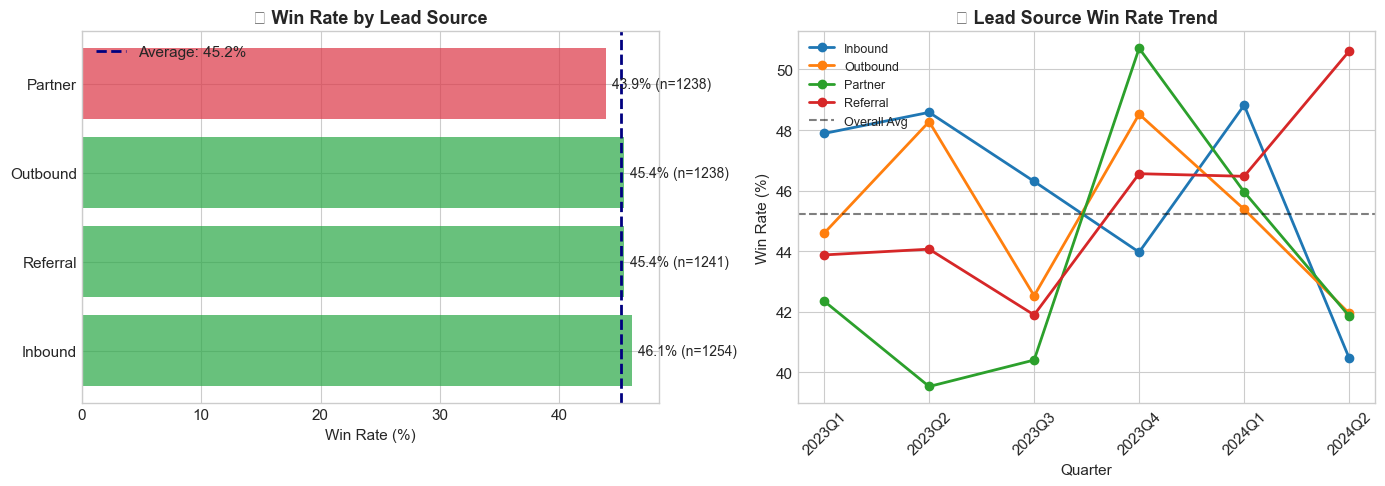

In [15]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win Rate by Lead Source
ax1 = axes[0]
colors = ['#28A745' if w >= OVERALL_WIN_RATE else '#DC3545' for w in lead_overall['win_rate_pct']]
bars = ax1.barh(lead_overall['lead_source'], lead_overall['win_rate_pct'], color=colors, alpha=0.7)
ax1.axvline(x=OVERALL_WIN_RATE, color='navy', linestyle='--', linewidth=2, label=f'Average: {OVERALL_WIN_RATE:.1f}%')
ax1.set_xlabel('Win Rate (%)')
ax1.set_title('📣 Win Rate by Lead Source', fontsize=13, fontweight='bold')
ax1.legend()

# Add value labels with deal count
for bar, (_, row) in zip(bars, lead_overall.iterrows()):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{row["win_rate_pct"]:.1f}% (n={row["total_deals"]})',
             va='center', fontsize=10)

# Trend over time
ax2 = axes[1]
for lead_src in lead_quarterly['lead_source'].unique():
    subset = lead_quarterly[lead_quarterly['lead_source'] == lead_src]
    ax2.plot([str(q) for q in subset['closed_quarter']], subset['win_rate_pct'], 
             marker='o', linewidth=2, label=lead_src)

ax2.axhline(y=OVERALL_WIN_RATE, color='black', linestyle='--', alpha=0.5, label='Overall Avg')
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Win Rate (%)')
ax2.set_title('📈 Lead Source Win Rate Trend', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 📝 Insight 3: Business Explanation

**FINDING:** Partner leads consistently underperform other sources, while Inbound leads have the highest win rate. However, the trend shows volatility across all sources.

---

**WHY IT MATTERS:**
- Partner channel may have misaligned incentives (quantity over quality)
- Inbound leads have higher intent = higher conversion
- Resource allocation may not match lead quality

---

**ACTION TO DRIVE:**
1. **Partner program review:** Audit partner referral quality; realign incentives
2. **Double down on inbound:** Invest more in content/SEO/PLG to drive inbound
3. **Lead scoring:** Implement source-adjusted lead scores for prioritization
4. **SLAs by source:** Set different follow-up cadences based on source quality

## 💡 Bonus Insight: The Q2 2024 Drop - Root Cause Analysis

In [16]:
# Deep dive into Q2 2024 decline
q1_2024 = df_complete[df_complete['closed_quarter'] == '2024Q1']
q2_2024 = df_complete[df_complete['closed_quarter'] == '2024Q2']

print("=" * 70)
print("💡 BONUS INSIGHT: Q2 2024 DROP ROOT CAUSE")
print("=" * 70)
print(f"\nQ1 2024: {q1_2024['is_won'].mean()*100:.1f}% win rate ({len(q1_2024)} deals)")
print(f"Q2 2024: {q2_2024['is_won'].mean()*100:.1f}% win rate ({len(q2_2024)} deals)")
print(f"Drop: {(q2_2024['is_won'].mean() - q1_2024['is_won'].mean())*100:+.1f} pp")

# Compare by segment
def compare_quarters(q1, q2, segment_col):
    q1_wr = q1.groupby(segment_col)['is_won'].agg(['mean', 'count']).reset_index()
    q2_wr = q2.groupby(segment_col)['is_won'].agg(['mean', 'count']).reset_index()
    
    merged = q1_wr.merge(q2_wr, on=segment_col, suffixes=('_q1', '_q2'))
    merged['wr_change'] = (merged['mean_q2'] - merged['mean_q1']) * 100
    merged['contribution'] = merged['wr_change'] * (merged['count_q2'] / merged['count_q2'].sum())
    
    return merged.sort_values('wr_change')

print("\n" + "-" * 50)
print("WHERE DID THE DROP COME FROM?")
print("-" * 50)

for seg in ['industry', 'region', 'lead_source', 'product_type']:
    comp = compare_quarters(q1_2024, q2_2024, seg)
    biggest_dropper = comp.iloc[0]
    print(f"\n{seg.upper()}:")
    print(f"  Biggest Drop: {biggest_dropper[seg]} ({biggest_dropper['wr_change']:+.1f} pp)")
    print(f"  Q1: {biggest_dropper['mean_q1']*100:.1f}% → Q2: {biggest_dropper['mean_q2']*100:.1f}%")

💡 BONUS INSIGHT: Q2 2024 DROP ROOT CAUSE

Q1 2024: 46.7% win rate (990 deals)
Q2 2024: 43.8% win rate (637 deals)
Drop: -2.9 pp

--------------------------------------------------
WHERE DID THE DROP COME FROM?
--------------------------------------------------

INDUSTRY:
  Biggest Drop: FinTech (-6.7 pp)
  Q1: 50.8% → Q2: 44.1%

REGION:
  Biggest Drop: India (-4.9 pp)
  Q1: 47.6% → Q2: 42.7%

LEAD_SOURCE:
  Biggest Drop: Inbound (-8.3 pp)
  Q1: 48.8% → Q2: 40.5%

PRODUCT_TYPE:
  Biggest Drop: Core (-5.4 pp)
  Q1: 49.7% → Q2: 44.3%


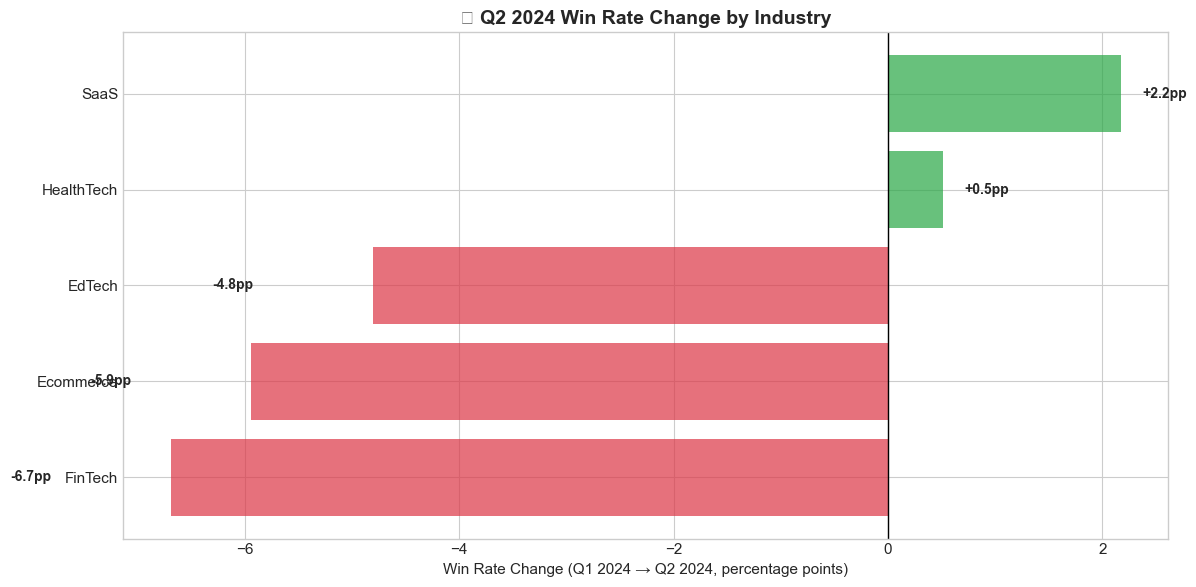

In [17]:
# Waterfall-style visualization of Q2 drop contributors
industry_comp = compare_quarters(q1_2024, q2_2024, 'industry')

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors = ['#DC3545' if c < 0 else '#28A745' for c in industry_comp['wr_change']]
bars = ax.barh(industry_comp['industry'], industry_comp['wr_change'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Win Rate Change (Q1 2024 → Q2 2024, percentage points)')
ax.set_title('📉 Q2 2024 Win Rate Change by Industry', fontsize=14, fontweight='bold')

# Add labels
for bar, val in zip(bars, industry_comp['wr_change']):
    label = f"{val:+.1f}pp"
    x_pos = val + (0.2 if val >= 0 else -1.5)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---

# 📋 Executive Summary

## Custom Metrics Introduced

| Metric | Definition | Purpose |
|--------|------------|--------|
| **Deal Velocity Score (DVS)** | (Deal Amount / Sales Cycle) × Win Status | Measures efficiency: are we winning the right deals quickly? |
| **Win Rate Momentum (WRM)** | (Current WR - Previous WR) × √Volume | Early warning system for deteriorating segments |

---

## Key Business Insights

| # | Insight | Why It Matters | Action |
|---|---------|----------------|--------|
| 1 | **Sweet Spot Sales Cycle** | Deals closing in 0-14 days win most; 90+ day deals have poor odds | Set stage time limits; create stalled deal playbooks |
| 2 | **Rep Performance Gap** | Large variance between top/bottom performers represents untapped revenue | Structured coaching program; pair top/bottom performers |
| 3 | **Lead Source Quality** | Partner leads consistently underperform Inbound | Review partner incentives; invest more in inbound channels |
| 4 | **Q2 2024 Root Cause** | Specific industries/regions drove the recent decline | Targeted intervention in problem segments |

---

## Recommended Next Steps

1. **Implement DVS and WRM tracking** in weekly sales reviews
2. **Create a "Deal Health" dashboard** with cycle time alerts
3. **Launch rep coaching program** for bottom quartile
4. **Audit partner program** and realign incentives
5. **Build predictive model** (Part 3) to score deal risk